# Production notebook building masking like an agent would do it

The goal of this notebook is to go through what an agent should do when producing a mask for a given run, and use this exploration to identify simplifications and clarifications necessary in the codebase.

**Plan** (input = RUN):
1. Explore content of the run + associated calibration data 
```python
list_contents(RUN)
# Should list number of shots, different properties, number of shots available per property, calibration data available
# Geometry of the detector etc ...
```
2. Shot selection : based on content, decide on several shot selections and run them
```python
select_shots(...) # Selection 1
select_shots(...) # Selection 2
select_shots(...) # Selection 3
display_shots() # Displays shots together for visual analysis and refine/discard some if necessary
```
3. Masking : based on observed shots, decide what masking tools to use and apply them (always apply geometry + calib first)
```python
detector(...) # Masking : includes stats, regularization etc ...
display_masks() # Display each mask obtained and refine parameters or tools if necessary
```
4. Validation : based on obtained masks, apply validation methods to refine previous behavior if necessary
```python
raise(NotImplemented)
```

In [9]:
from automask.utils import configure_psana_environment

PSANA_ENVIRONMENT = configure_psana_environment()

## 0. Experiment content

This first stage only identifies the experiment and resolves the files relevant to the requested run and detector. It does not open or analyze any data. In practice, the agent should recover this context; it is explicit here so the notebook remains reproducible.

Inputs to clarify before starting:
1. Experiment name
2. Run number
3. Detector alias, psana source, and calibration type
4. Data paths: find the run's `.xtc` streams and the detector calibration files applicable to that run.

Expected output:
```markdown
Experiment: ""
Run: ""
Detector: ""
Relevant files:
- XTC files (Markdown table)
- Applicable detector calibration files (Markdown table)
```

In [10]:
# Hardcoded information for this run

from automask.io.read_xtc import JUNGFRAU_NAME

EXPERIMENT_NAME = 'xppl1016922'
RUN = 475
DETECTOR_NAME = JUNGFRAU_NAME
DETECTOR_SOURCE = 'XppEndstation.0:Jungfrau.0'
DETECTOR_CALIB_TYPE = 'Jungfrau::CalibV1'

In [11]:
from automask.utils import (
    list_experiment_content,
    profile_run_values,
    print_detector_geometry,
)

In [12]:
experiment_content = list_experiment_content(
    EXPERIMENT_NAME, RUN, DETECTOR_NAME, DETECTOR_SOURCE, DETECTOR_CALIB_TYPE
)
xtc = experiment_content['xtc']

**Experiment:** `xppl1016922`  
**Run:** `0475`  
**Detector:** `jungfrau1M_alcove` (`XppEndstation.0:Jungfrau.0`)

### Relevant XTC files

| file | stream | chunk | size | path |
| --- | --- | --- | --- | --- |
| xppl1016922-r0475-s00-c00.xtc | s00 | c00 | 1.27 GiB | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s00-c00.xtc |
| xppl1016922-r0475-s01-c00.xtc | s01 | c00 | 1.27 GiB | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s01-c00.xtc |

### Applicable detector calibration files

| constant | run range | size | path |
| --- | --- | --- | --- |
| dark_max | 362–end | 21.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/dark_max/362-end.data |
| dark_min | 362–end | 21.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/dark_min/362-end.data |
| geometry | 0–end | 1.71 KiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/geometry/0-end.data |
| pedestals | 362–end | 28.99 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pedestals/362-end.data |
| pixel_gain | 110–end | 24.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_gain/110-end.data |
| pixel_offset | 110–end | 14.98 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_offset/110-end.data |
| pixel_rms | 362–end | 18.32 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_rms/362-end.data |
| pixel_status | 362–end | 15.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_status/362-end.data |

## 1. Analysis of the listed files

This stage is reached once the available files and XTC keys have been listed. It profiles their values, reads detector geometry, and analyzes the relevant calibration constants.

At this stage, available and confirmed information should be:
1. RUN
2. Experiment name
3. Detector alias 
4. XTC and calibration files

### Profile XTC and EPICS values and geometry

The run profiler discovers payloads directly from `event.keys()` and extracts the known numeric fields from every decoded event. After each event it also records the current value of every process variable in `data_source.env().epicsStore()`, including both its alias and underlying PV name. It does not require experiment-specific payload or value definitions.

```python
run_profile = profile_run_values(RUN)
print_detector_geometry(RUN)
```

In [13]:
run_profile = profile_run_values(RUN)
print_detector_geometry(RUN)

could not find EPICS PV lxt_ttc in data
could not find EPICS PV las_opa_wp in data
Timetool detector not found in data.


### Raw XTC payloads (1,280 decoded events)

| source | alias | type | key | coverage | read errors |
| --- | --- | --- | --- | --- | --- |
| BldInfo(EBeam) | — | Bld.BldDataEBeamV7 | — | 100.0% | 0 |
| BldInfo(FEE-SPEC0) | — | Bld.BldDataSpectrometerV1 | — | 77.7% | 0 |
| BldInfo(FEEGasDetEnergy) | — | Bld.BldDataFEEGasDetEnergyV1 | — | 99.9% | 0 |
| BldInfo(HX2-SB1-BMMON) | — | Bld.BldDataBeamMonitorV1 | — | 100.0% | 0 |
| BldInfo(PhaseCavity) | — | Bld.BldDataPhaseCavityV1 | — | 99.1% | 0 |
| BldInfo(XPP-AIN-01) | — | Bld.BldDataAnalogInputV1 | — | 100.0% | 0 |
| BldInfo(XPP-SB2-BMMON) | — | Bld.BldDataBeamMonitorV1 | — | 100.0% | 0 |
| BldInfo(XPP-SB3-BMMON) | — | Bld.BldDataBeamMonitorV1 | — | 100.0% | 0 |
| BldInfo(XppEnds_Ipm0) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppEnds_Ipm0) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim0) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim0) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim1) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim1) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| BldInfo(XppSb3_Pim) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppSb3_Pim) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| DetInfo(NoDetector.0:Evr.0) | evr0 | EvrData.DataV4 | — | 100.0% | 0 |
| DetInfo(XppEndstation.0:Jungfrau.0) | jungfrau1M_alcove | Jungfrau.ElementV2 | — | 100.0% | 0 |
| ProcInfo(255.255.255.255, pid=16777215) | — | psana.DgramList | — | 100.0% | 0 |
| ProcInfo(255.255.255.255, pid=16777215) | — | psana.EventId | — | 100.0% | 0 |
| ProcInfo(255.255.255.255, pid=16777215) | — | psana.EventOffset | — | 100.0% | 0 |
| ProcInfo(255.255.255.255, pid=16777215) | — | — | — | 100.0% | 0 |

### Profiled per-shot values

| source | field | type | origin | coverage | variation | observed |
| --- | --- | --- | --- | --- | --- | --- |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | charge1 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 1239 values | p05=7.333e+04, median=7.509e+04, p95=7.7e+04 |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | charge2 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 784 values | p05=37.2, median=96.6, p95=191.3 |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | fitTime1 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 720 values | p05=-0.8869, median=-0.6773, p95=-0.4483 |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | fitTime2 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 1267 values | p05=-111.1, median=7.049, p95=131.1 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[137] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 22 changes | 0: 11, 1: 1269 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[141] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 729 changes | 0: 626, 1: 654 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[142] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 551 changes | 0: 967, 1: 313 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[143] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 208 changes | 0: 1176, 1: 104 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[144] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 112 changes | 0: 1224, 1: 56 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[145] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 26 changes | 0: 1267, 1: 13 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[146] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 14 changes | 0: 1273, 1: 7 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[162] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 22 changes | 0: 1269, 1: 11 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[31] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 729 changes | 0: 626, 1: 654 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[32] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 551 changes | 0: 967, 1: 313 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[33] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 208 changes | 0: 1176, 1: 104 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[34] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 112 changes | 0: 1224, 1: 56 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[35] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 26 changes | 0: 1267, 1: 13 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[36] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 14 changes | 0: 1273, 1: 7 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[41] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 729 changes | 0: 626, 1: 654 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[42] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 551 changes | 0: 967, 1: 313 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[43] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 208 changes | 0: 1176, 1: 104 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[44] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 112 changes | 0: 1224, 1: 56 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[45] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 26 changes | 0: 1267, 1: 13 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[46] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 14 changes | 0: 1273, 1: 7 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[90] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 639 changes | 0: 415, 1: 865 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[91] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 639 changes | 0: 865, 1: 415 |
| DetInfo(XppEndstation.0:Jungfrau.0)/Jungfrau.ElementV2 | fiducials | Jungfrau.ElementV2 | psana payload | 100.0% | continuous; 1280 values | p05=4.552e+04, median=4.984e+04, p95=5.415e+04 |
| DetInfo(XppEndstation.0:Jungfrau.0)/Jungfrau.ElementV2 | frameNumber | Jungfrau.ElementV2 | psana payload | 100.0% | continuous; 1280 values | p05=3.975e+05, median=3.99e+05, p95=4.004e+05 |
| DetInfo(XppEndstation.0:Jungfrau.0)/Jungfrau.ElementV2 | ticks | Jungfrau.ElementV2 | psana payload | 100.0% | 3 values; 735 changes | 328166: 35, 329832: 614, 331498: 631 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.DgramList | getFileNames[0] | psana.DgramList | psana payload | 100.0% | 2 values; 990 changes | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s00-c00.xtc: 640, /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s01-c00.xtc: 640 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.DgramList | getOffsets[0] | psana.DgramList | psana payload | 100.0% | continuous; 1278 values | p05=6.782e+07, median=6.785e+08, p95=1.29e+09 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | fiducials | psana.EventId | psana payload | 100.0% | continuous; 1280 values | p05=4.552e+04, median=4.984e+04, p95=5.415e+04 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | ticks | psana.EventId | psana payload | 100.0% | 3 values; 735 changes | 328166: 35, 329832: 614, 331498: 631 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | time[0] | psana.EventId | psana payload | 100.0% | continuous; 27 values | p05=1.72e+09, median=1.72e+09, p95=1.72e+09 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | time[1] | psana.EventId | psana payload | 100.0% | continuous; 1280 values | p05=4.457e+07, median=4.924e+08, p95=9.436e+08 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | vector | psana.EventId | psana payload | 100.0% | continuous; 1280 values | p05=4321, median=5759, p95=7197 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventOffset | filenames[0] | psana.EventOffset | psana payload | 100.0% | 2 values; 990 changes | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s00-c00.xtc: 640, /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s01-c00.xtc: 640 |
| ai | ch00 | smalldata_tools | smalldata_tools | 100.0% | continuous; 18 values | p05=-0.001526, median=0, p95=0.001221 |
| ai | ch01 | smalldata_tools | smalldata_tools | 100.0% | continuous; 29 values | p05=-0.001526, median=0.0006104, p95=0.002747 |
| ai | ch02 | smalldata_tools | smalldata_tools | 100.0% | continuous; 86 values | p05=5.039, median=5.049, p95=5.057 |
| ai | ch03 | smalldata_tools | smalldata_tools | 100.0% | continuous; 19 values | p05=0.04364, median=0.04486, p95=0.04608 |
| ai | ch04 | smalldata_tools | smalldata_tools | 100.0% | 10 values; 899 changes | -0.0015258789: 1, -0.0012207031: 10, -0.00091552734: 19, -0.00061035156: 36, -0.00030517578: 456, 0: 440, 0.00030517578: 241, 0.00061035156: 59, 0.00091552734: 14, 0.0012207031: 4 |
| ai | ch05 | smalldata_tools | smalldata_tools | 100.0% | 10 values; 956 changes | -0.0015258789: 1, -0.0012207031: 2, -0.00091552734: 30, -0.00061035156: 105, -0.00030517578: 362, 0: 450, 0.00030517578: 251, 0.00061035156: 62, 0.00091552734: 13, 0.0012207031: 4 |
| ai | ch06 | smalldata_tools | smalldata_tools | 100.0% | continuous; 22 values | p05=-0.0003052, median=0.001221, p95=0.002747 |
| ai | ch07 | smalldata_tools | smalldata_tools | 100.0% | continuous; 27 values | p05=0, median=0.002136, p95=0.003967 |
| ai | ch08 | smalldata_tools | smalldata_tools | 100.0% | continuous; 27 values | p05=-0.001221, median=0.0009155, p95=0.003357 |
| ai | ch09 | smalldata_tools | smalldata_tools | 100.0% | continuous; 27 values | p05=0.0003052, median=0.002441, p95=0.004883 |
| ai | ch10 | smalldata_tools | smalldata_tools | 100.0% | continuous; 26 values | p05=0.0009155, median=0.002747, p95=0.004883 |
| ai | ch11 | smalldata_tools | smalldata_tools | 100.0% | continuous; 26 values | p05=0.001526, median=0.003357, p95=0.005188 |
| ai | ch12 | smalldata_tools | smalldata_tools | 100.0% | continuous; 24 values | p05=0.0006104, median=0.002136, p95=0.003967 |
| ai | ch13 | smalldata_tools | smalldata_tools | 100.0% | continuous; 24 values | p05=0.001221, median=0.003052, p95=0.004883 |
| ai | ch14 | smalldata_tools | smalldata_tools | 100.0% | continuous; 23 values | p05=0.002136, median=0.003967, p95=0.005493 |
| ai | ch15 | smalldata_tools | smalldata_tools | 100.0% | continuous; 22 values | p05=0.001526, median=0.003357, p95=0.004883 |
| damage | FEEGasDetEnergy | smalldata_tools | smalldata_tools | 100.0% | 2 values; 2 changes | 0: 1, 1: 1279 |
| damage | FEE_SPEC0 | smalldata_tools | smalldata_tools | 100.0% | 2 values; 3 changes | 0: 286, 1: 994 |
| damage | PhaseCavity | smalldata_tools | smalldata_tools | 100.0% | 2 values; 22 changes | 0: 11, 1: 1269 |
| damage | feeBld | smalldata_tools | smalldata_tools | 100.0% | 2 values; 3 changes | 0: 286, 1: 994 |
| diode2 | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 372 values | p05=0, median=0.005646, p95=0.03275 |
| diode2 | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1140 values | p05=0.002132, median=0.976, p95=2.46 |
| diode2 | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 24 values | p05=0, median=7.63e-05, p95=0.0006867 |
| diode2 | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 481 values | p05=0, median=0.00988, p95=0.05967 |
| diode2 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1192 values | p05=0.003964, median=0.9911, p95=2.539 |
| diodeU | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 137 values | p05=-0.0001955, median=0.001941, p95=0.008433 |
| diodeU | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 81 values | p05=-0.0004352, median=0.0007092, p95=0.003151 |
| diodeU | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 493 values | p05=-8.679e-05, median=0.009259, p95=0.05497 |
| diodeU | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 41 values | p05=-7.216e-05, median=4.133e-06, p95=0.002293 |
| diodeU | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 577 values | p05=-2.67e-05, median=0.01222, p95=0.0683 |
| ebeam | damageMask | smalldata_tools | smalldata_tools | 100.0% | continuous; 11 values | p05=4.921e+04, median=4.921e+04, p95=6.483e+04 |
| ebeam | ebeamCharge | smalldata_tools | smalldata_tools | 100.0% | continuous; 1278 values | p05=0.2716, median=0.2803, p95=0.2889 |
| ebeam | ebeamDumpCharge | smalldata_tools | smalldata_tools | 100.0% | continuous; 1273 values | p05=1.275e+09, median=1.306e+09, p95=1.339e+09 |
| ebeam | ebeamEnergyBC1 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.1878, median=0.000584, p95=0.1882 |
| ebeam | ebeamEnergyBC2 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.5698, median=-0.01574, p95=0.6226 |
| ebeam | ebeamL3Energy | smalldata_tools | smalldata_tools | 100.0% | continuous; 1279 values | p05=1.05e+04, median=1.051e+04, p95=1.052e+04 |
| ebeam | ebeamLTU250 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.04945, median=0.06097, p95=0.1473 |
| ebeam | ebeamLTU450 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1279 values | p05=0.009887, median=0.09368, p95=0.1987 |
| ebeam | ebeamPhotonEnergy | smalldata_tools | smalldata_tools | 100.0% | continuous; 1279 values | p05=9546, median=9564, p95=9579 |
| ebeam | ebeamPkCurrBC1 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1069 values | p05=220, median=227.5, p95=235.5 |
| ebeam | ebeamPkCurrBC2 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=2898, median=3683, p95=5220 |
| ebeam | ebeamUndAngX | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=0.0002642, median=0.001043, p95=0.001886 |
| ebeam | ebeamUndAngY | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=-0.001186, median=-0.0004992, p95=0.0001981 |
| ebeam | ebeamUndPosX | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=-0.02274, median=-0.007007, p95=0.005864 |
| ebeam | ebeamUndPosY | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=-0.02529, median=-0.01481, p95=-0.004474 |
| gas_detector | f_11_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1276 values | p05=0.1236, median=0.2547, p95=0.4316 |
| gas_detector | f_12_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1273 values | p05=0.1237, median=0.2538, p95=0.4339 |
| gas_detector | f_21_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1275 values | p05=0.1162, median=0.2399, p95=0.4086 |
| gas_detector | f_22_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1272 values | p05=0.1018, median=0.2169, p95=0.3704 |
| gas_detector | f_63_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1266 values | p05=0.09206, median=0.2006, p95=0.3425 |
| gas_detector | f_64_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1279 values | p05=0.1067, median=0.2124, p95=0.2845 |
| ipm2 | peaks[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 276 values | p05=-12.38, median=-0.375, p95=13.26 |
| ipm2 | peaks[10] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1214 values | p05=2.744, median=757.2, p95=4017 |
| ipm2 | peaks[11] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1211 values | p05=3.119, median=827.6, p95=4374 |
| ipm2 | peaks[12] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1209 values | p05=3.375, median=739.8, p95=3912 |
| ipm2 | peaks[13] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1028 values | p05=0.125, median=128.5, p95=683.6 |
| ipm2 | peaks[14] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1053 values | p05=-0.25, median=131.1, p95=693.8 |
| ipm2 | peaks[15] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1064 values | p05=0.5, median=173.3, p95=931.2 |
| ipm2 | peaks[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 229 values | p05=-11.13, median=-0.125, p95=9.5 |
| ipm2 | peaks[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 394 values | p05=-20, median=-0.375, p95=22.25 |
| ipm2 | peaks[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 209 values | p05=-10.25, median=0.375, p95=8.625 |
| ipm2 | peaks[4] | smalldata_tools | smalldata_tools | 100.0% | continuous; 190 values | p05=-8.631, median=0.375, p95=7.756 |
| ipm2 | peaks[5] | smalldata_tools | smalldata_tools | 100.0% | continuous; 197 values | p05=-7.875, median=-0.25, p95=8.506 |
| ipm2 | peaks[6] | smalldata_tools | smalldata_tools | 100.0% | continuous; 200 values | p05=-9.125, median=0.125, p95=8.006 |
| ipm2 | peaks[7] | smalldata_tools | smalldata_tools | 100.0% | continuous; 189 values | p05=-7.881, median=-0.375, p95=8 |
| ipm2 | peaks[8] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1045 values | p05=0.875, median=150.6, p95=785.4 |
| ipm2 | peaks[9] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1209 values | p05=3.75, median=837, p95=4426 |
| ipm2 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1261 values | p05=14.37, median=3746, p95=1.981e+04 |
| ipm2 | xpos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1274 values | p05=-0.6202, median=-0.07116, p95=0.2373 |
| ipm2 | ypos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1272 values | p05=-1.279, median=-0.2982, p95=2.493 |
| ipm3 | peaks[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1032 values | p05=-0.375, median=137.1, p95=813.4 |
| ipm3 | peaks[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1047 values | p05=-868.1, median=-150.5, p95=-0.125 |
| ipm3 | peaks[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1180 values | p05=1.375, median=576.2, p95=2465 |
| ipm3 | peaks[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1193 values | p05=-2432, median=-586.1, p95=-1.875 |
| ipm3 | peaks[4] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1182 values | p05=1.5, median=563.3, p95=2658 |
| ipm3 | peaks[5] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1016 values | p05=-635.2, median=-106.5, p95=0.125 |
| ipm3 | peaks[6] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1047 values | p05=0.3688, median=137.1, p95=805.1 |
| ipm3 | peaks[7] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1198 values | p05=-2688, median=-632.5, p95=-2.744 |
| ipm3 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1256 values | p05=7.5, median=2906, p95=1.365e+04 |
| ipm3 | xpos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1032 values | p05=-0.375, median=137.1, p95=813.4 |
| ipm3 | ypos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1032 values | p05=-0.375, median=137.1, p95=813.4 |
| ipm_hx2 | peaks[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 212 values | p05=-10.63, median=0.5, p95=7.756 |
| ipm_hx2 | peaks[10] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1275 values | p05=8456, median=1.73e+04, p95=2.886e+04 |
| ipm_hx2 | peaks[11] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1273 values | p05=1.14e+04, median=2.317e+04, p95=3.863e+04 |
| ipm_hx2 | peaks[12] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1277 values | p05=8193, median=1.663e+04, p95=2.773e+04 |
| ipm_hx2 | peaks[13] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1265 values | p05=1922, median=3957, p95=6600 |
| ipm_hx2 | peaks[14] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1261 values | p05=2018, median=4121, p95=6837 |
| ipm_hx2 | peaks[15] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1206 values | p05=511.7, median=1123, p95=1925 |
| ipm_hx2 | peaks[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 215 values | p05=-8.75, median=-0.25, p95=9.5 |
| ipm_hx2 | peaks[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 234 values | p05=-10.12, median=-0.125, p95=10.12 |
| ipm_hx2 | peaks[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 229 values | p05=-10.12, median=0, p95=9.625 |
| ipm_hx2 | peaks[4] | smalldata_tools | smalldata_tools | 100.0% | continuous; 199 values | p05=-7.375, median=-0.25, p95=8 |
| ipm_hx2 | peaks[5] | smalldata_tools | smalldata_tools | 100.0% | continuous; 235 values | p05=-10.12, median=-0.125, p95=9.25 |
| ipm_hx2 | peaks[6] | smalldata_tools | smalldata_tools | 100.0% | continuous; 169 values | p05=-7.131, median=-0.0625, p95=6.881 |
| ipm_hx2 | peaks[7] | smalldata_tools | smalldata_tools | 100.0% | continuous; 185 values | p05=-7.506, median=-0.125, p95=6.875 |
| ipm_hx2 | peaks[8] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1162 values | p05=264.6, median=574.6, p95=967.4 |
| ipm_hx2 | peaks[9] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1276 values | p05=1.136e+04, median=2.326e+04, p95=3.876e+04 |
| ipm_hx2 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1278 values | p05=4.406e+04, median=9.011e+04, p95=1.503e+05 |
| ipm_hx2 | xpos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.05134, median=0.06246, p95=0.1573 |
| ipm_hx2 | ypos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.2836, median=-0.2187, p95=-0.1493 |
| lombpm | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 262 values | p05=0, median=0.007706, p95=0.05025 |
| lombpm | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 50 values | p05=0, median=0, p95=0.002441 |
| lombpm | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 456 values | p05=0, median=0.007706, p95=0.05059 |
| lombpm | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 47 values | p05=0, median=0.0001907, p95=0.00206 |
| lombpm | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 668 values | p05=7.63e-05, median=0.01732, p95=0.101 |
| lomdiode | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1154 values | p05=0.006783, median=0.2218, p95=0.8158 |
| lomdiode | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1229 values | p05=0.2149, median=0.6242, p95=1.28 |
| lomdiode | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 45 values | p05=0, median=0.0002289, p95=0.001526 |
| lomdiode | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 18 values | p05=0, median=0.0001526, p95=0.0006867 |
| lomdiode | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1245 values | p05=0.231, median=0.8559, p95=2.068 |

### EPICS process variables

| alias | PV | dtype | coverage | variation | observed |
| --- | --- | --- | --- | --- | --- |
| Sample_Temp_MON | XPP:USR:TCT:01:GET_TEMP_D | float64 | 100.0% | continuous; 26 values | p05=296.6, median=296.6, p95=296.7 |
| Sample_Temp_PID | XPP:USR:TCT:01:GET_TEMP_C | float64 | 100.0% | continuous; 23 values | p05=298.3, median=298.4, p95=298.4 |
| att_E | XPP:ATT:COM:T_CALC.VALE | float64 | 100.0% | continuous; 15 values | p05=9553, median=9565, p95=9569 |
| ccm_alio_position_get | XPP:MON:MPZ:07A:POSITIONGET | float64 | 100.0% | 8 values; 201 changes | -29.784316: 5, -29.784312: 13, -29.784307: 107, -29.784302: 380, -29.784297: 396, -29.784292: 308, -29.784287: 68, -29.784282: 3 |
| ccm_alio_position_raw | XPP:MON:MPZ:07A:POSITIONRAWGET | float64 | 100.0% | 8 values; 201 changes | 190619.41: 3, 190619.44: 68, 190619.47: 308, 190619.5: 396, 190619.53: 380, 190619.56: 107, 190619.59: 13, 190619.62: 5 |
| ccm_pi_position | XPP:MON:MPZ:08:POSITIONGET | float64 | 100.0% | 6 values; 5 changes | 5: 157, 5.0001: 239, 5.0002: 240, 5.0004: 164, 5.0006: 240, 5.0015: 240 |
| delay | XPP:ENS:01:m0.RBV | float64 | 100.0% | 4 values; 13 changes | 8.430485: 124, 8.43049: 232, 8.430495: 652, 8.4305: 272 |
| eBeam_peak_current_after_second_bunch_compressor | SIOC:SYS0:ML00:AO195 | float64 | 100.0% | continuous; 15 values | p05=3227, median=3686, p95=4250 |
| eBeam_pulse_length | SIOC:SYS0:ML00:AO820 | float64 | 100.0% | continuous; 15 values | p05=49.46, median=56.37, p95=66.8 |
| em1l01_PMT_voltage_242 | HVCH:FEE1:242:VoltageMeasure | float64 | 100.0% | continuous; 42 values | p05=750, median=750, p95=750 |
| em1l0_GEM_10T_pressure | EM1L0:GEM:GCM:41:PRESS_RBV | float64 | 100.0% | continuous; 17 values | p05=1.956, median=2.026, p95=2.028 |
| em1l0_PMT_voltage_241 | HVCH:FEE1:241:VoltageMeasure | float64 | 100.0% | continuous; 45 values | p05=750, median=750, p95=750 |
| em2l0_GEM_10T_pressure | EM2L0:GEM:GCM:41:PRESS_RBV | float64 | 100.0% | continuous; 17 values | p05=1.941, median=1.956, p95=1.957 |
| em2l0_PMT_voltage_361 | HVCH:FEE1:361:VoltageMeasure | float64 | 100.0% | continuous; 44 values | p05=800, median=800, p95=800 |
| em2l0_PMT_voltage_362 | HVCH:FEE1:362:VoltageMeasure | float64 | 100.0% | continuous; 52 values | p05=910, median=910, p95=910 |
| fee_SolidAttenuator_E | SATT:FEE1:320:ETOA.E | float64 | 100.0% | continuous; 16 values | p05=9553, median=9565, p95=9570 |
| fee_mr1l0_homs_gantry_x | MR1L0:HOMS:GANTRY_X_RBV | float64 | 100.0% | continuous; 17 values | p05=-6.39, median=-6.37, p95=-6.355 |
| fee_mr1l0_homs_x_up | MR1L0:HOMS:MMS:XUP.RBV | float64 | 100.0% | continuous; 19 values | p05=0.658, median=0.67, p95=0.677 |
| fee_mr2l0_homs_gantry_x | MR2L0:HOMS:GANTRY_X_RBV | float64 | 100.0% | continuous; 17 values | p05=-6.17, median=-6.158, p95=-6.147 |
| fee_mr2l0_homs_x_up | MR2L0:HOMS:MMS:XUP.RBV | float64 | 100.0% | continuous; 16 values | p05=-22.07, median=-22.06, p95=-22.05 |
| las_Counter_Readback_ns | LAS:FS11:VIT:FS_CTR_TIME | float64 | 100.0% | continuous; 15 values | p05=5413, median=5413, p95=5413 |
| lib_mcs_m1 | XPP:MCS2:01:m1.RBV | float64 | 100.0% | 8 values; 20 changes | -25.055157: 62, -25.055155: 153, -25.055154: 102, -25.055153: 265, -25.055152: 308, -25.055151: 288, -25.055149: 51, -25.055147: 51 |
| lib_mcs_m7 | XPP:MCS2:01:m7.RBV | float64 | 100.0% | 6 values; 21 changes | 4.999997: 51, 4.999998: 153, 4.999999: 381, 5: 460, 5.000001: 184, 5.000002: 51 |
| photonBeam_Wavelength | SIOC:SYS0:ML00:AO192 | float64 | 100.0% | continuous; 15 values | p05=0.1296, median=0.1296, p95=0.1298 |
| photonBeam_energy_corr | SIOC:SYS0:ML00:AO627 | float64 | 100.0% | continuous; 15 values | p05=9553, median=9565, p95=9570 |
| robot_rad | XPP:ROB:POS:RAD | float64 | 100.0% | 2 values; 17 changes | 1038.253: 1000, 1038.254: 280 |
| robot_y | XPP:ROB:POS:Y | float64 | 100.0% | 2 values; 21 changes | 957.576: 308, 957.577: 972 |
| robot_z | XPP:ROB:POS:Z | float64 | 100.0% | 3 values; 25 changes | 393.287: 894, 393.288: 308, 393.289: 78 |
| scan_motor_0 | XPP:SCAN:SCANVAR00 | float64 | 0.0% | unavailable | no finite values |
| scan_motor_1 | XPP:SCAN:SCANVAR01 | float64 | 0.0% | unavailable | no finite values |
| scan_motor_2 | XPP:SCAN:SCANVAR02 | float64 | 0.0% | unavailable | no finite values |
| sl1l0_b | SL1L0:POWER:MMS:BOTTOM.RBV | float64 | 100.0% | 2 values; 7 changes | -14.49055: 270, -14.4905: 1010 |
| sl1l0_ho | SL1L0:POWER:ACTUAL_YCENTER_RBV | float64 | 100.0% | 3 values; 19 changes | 0.0001247902: 240, 0.0001497902: 706, 0.0001747902: 334 |
| sl1l0_hw | SL1L0:POWER:ACTUAL_YWIDTH_RBV | float64 | 100.0% | 3 values; 19 changes | 3.0013001: 133, 3.0013499: 574, 3.0014: 573 |
| sl1l0_n | SL1L0:POWER:MMS:NORTH.RBV | float64 | 100.0% | 2 values; 5 changes | 26.5513: 329, 26.55135: 951 |
| sl1l0_s | SL1L0:POWER:MMS:SOUTH.RBV | float64 | 100.0% | 2 values; 2 changes | -18.0513: 1201, -18.05125: 79 |
| sl1l0_t | SL1L0:POWER:MMS:TOP.RBV | float64 | 100.0% | 2 values; 8 changes | 22.94915: 987, 22.9492: 293 |
| sl1l0_vo | SL1L0:POWER:ACTUAL_XCENTER_RBV | float64 | 100.0% | 3 values; 19 changes | -0.0013252861: 530, -0.001300286: 561, -0.0012752861: 189 |
| sl1l0_vw | SL1L0:POWER:ACTUAL_XWIDTH_RBV | float64 | 100.0% | 3 values; 15 changes | 2.4999011: 186, 2.4999509: 720, 2.500001: 374 |
| vac_Gcc_hx3_mon_pmon01 | HX3:MON:GCC:01:PMON | float64 | 100.0% | 3 values; 5 changes | 9.1e-09: 96, 9.2e-09: 708, 9.3e-09: 476 |

### Jungfrau geometry

| property | value |
| --- | --- |
| detector | jungfrau1M_alcove |
| psana calibration path | /Data/hippolyte.wallaert/psdm/xpp/xppl1016922/calib |
| psana calibration path exists | True |
| native shape | (2, 512, 1024) |
| raw dtype | uint16 |
| calibrated frame available | True |
| index-map shape | (2, 512, 1024) |
| assembled shape | (1030, 1064) |

> [!warning] 
>
> Some key information is sometimes not available from the configuration files. Examples include sample-detector distance, ?? (#TODO include others). The agent should be able to identify this and either 
> 1. Retrieve if from log files or other sources
> 2. Ask the user for this information
> 3. Proceed to calibrate the distance itself from the data (if possible)

## 2. Shot selection

The profiler is an inventory, not an automatic selector. The practitioner supplies the small amount of experimental meaning that the files cannot provide: which fields and values define the scientifically relevant population. The agent writes those choices as ordinary comparisons over the profiled field names, checks the resulting counts, and only then decodes detector frames.

For this run the context is simple: EVR 137 is the genuine beam flag; `ai/ch02` (CC) is constant open and therefore adds no information; `ai/ch03` (VCC) is constant closed and selects the requested branch state; and `sample_diode` is downstream and suitable for trimming lit shots. Beam-off shots do not need an intensity field because no percentile trim or normalization is requested.

`ShotSelection` has no built-in beam or branch concepts. Another experiment can use completely different fields and values without changing the selection library. Conditions support `==`, `!=`, `<`, `<=`, `>`, `>=`, `between`, `in`, `not in`, `finite`, and `nonzero`; all conditions are combined with AND.

### Practitioner-defined selection recipe

In [14]:
from automask.shot_selection import Condition, PercentileTrim, ShotSelection

BEAM_ON_FIELD = 'DetInfo(NoDetector.0:Evr.0)/EvrData.DataV4/eventCode[137]'
VCC_FIELD = 'ai/ch03'
INTENSITY_FIELD = 'diodeU/channels[0]'

LIT_SELECTION = ShotSelection(
    where=(
        Condition(BEAM_ON_FIELD, '==', 1),
        Condition(VCC_FIELD, '<=', 2.0),
    ),
    trim=PercentileTrim(INTENSITY_FIELD, low=0.03, high=0.03),
    n_shots=800,
)

DARK_SELECTION = ShotSelection(
    where=(Condition(BEAM_ON_FIELD, '==', 0),),
)

[select] run 0475: 1280 shots total, 1269 eligible (fields=DetInfo(NoDetector.0:Evr.0)/EvrData.DataV4/eventCode[137],ai/ch03, trim=diodeU/channels[0]), 800 selected
[select] run 0475: 1280 shots total, 11 eligible (fields=DetInfo(NoDetector.0:Evr.0)/EvrData.DataV4/eventCode[137], trim=none), 11 selected


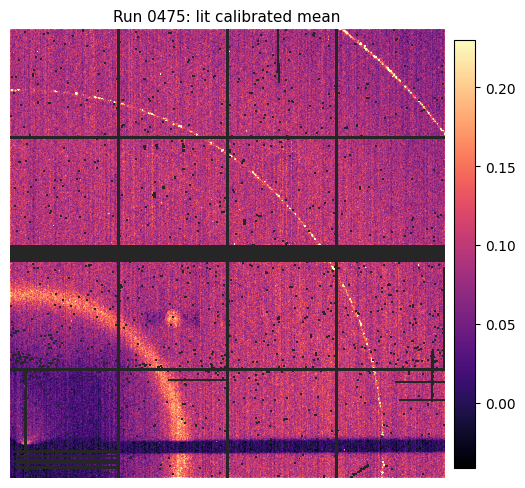

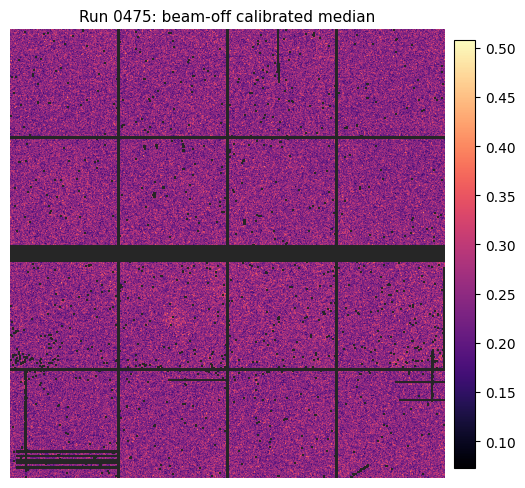

In [15]:
from automask.image_store import ImageStore
from automask.viz import show

requests = {
    'Lit calibrated mean': (LIT_SELECTION, 'mean'),
    'Beam-off calibrated median': (DARK_SELECTION, 'mad'),
}
store = ImageStore(run_profile=run_profile)
selected_images = {
    name: store.reduce(RUN, selection, reduction)
    for name, (selection, reduction) in requests.items()
}

for name, image in selected_images.items():
    show(image, title=f'Run {RUN:04d}: {name.lower()}')

## 3. Masking

When entering the masking stage, the agent has already profiled the run and selected a set of shots. The next step is to apply masking tools to the selected shots, starting with geometry and calibration masks.

### Practitioner-defined masking recipe

A `Pipeline` is one list of `Channel`s and a combiner. A channel is one statistic plus the stages around it, and whether it belongs to the intensity-free floor is read from the statistic's registered kind — not declared a second time. So `geometry` and `status_as_mask` are configured exactly like `blackhat`, and their knobs are reachable the same way.

`status_as_mask` is psana's per-run pixel status, read through `psana.Detector` at the run being masked. Nothing here loads a frozen array.

`Sample.from_store` then materializes exactly the arrays `MASKING_PIPELINE.needs()` asks for: names that are reductions are computed over `LIT_SELECTION`'s shots (already cached from the cell above), and every other name is passed to psana as a calibration accessor.

[select] run 0475: 1280 shots total, 1269 eligible (fields=DetInfo(NoDetector.0:Evr.0)/EvrData.DataV4/eventCode[137],ai/ch03, trim=diodeU/channels[0]), 800 selected


<Axes: title={'center': 'Run 0475: 9.99% masked'}>

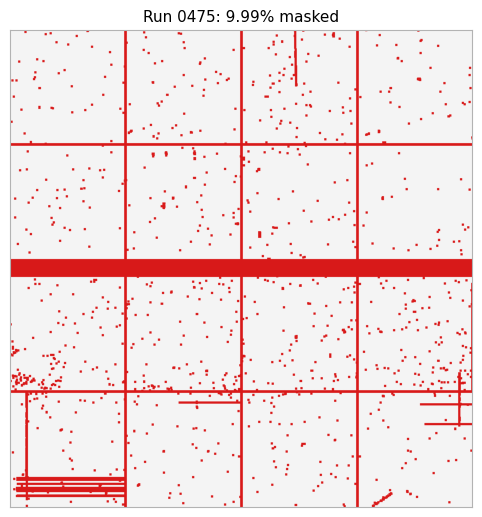

In [16]:
from automask.masking import Channel, Pipeline
from automask.sample import Sample
from automask.stats.blackhat import BlackhatParams
from automask.stats.geometry import GeometryParams
from automask.stats.status_as_mask import StatusAsMaskParams
from automask.regularization.tv import TVParams
from automask.regularization.pad import PadParams
from automask.viz import show_mask

MASKING_PIPELINE = Pipeline(
    channels=[
        Channel('geometry', GeometryParams(pad=2, frac=0.4), field_reg=None),
        Channel('status_as_mask', StatusAsMaskParams(pad=2), field_reg=None),
        Channel(
            'blackhat',
            BlackhatParams(radius=5, k=6.0, mode='high'),
            field_reg='tv',
            field_reg_params=TVParams(weight=1.0),
            mask_reg='pad',
            mask_reg_params=PadParams(pad=2),
        ),
    ],
    combiner='union',
)

sample = Sample.from_store(RUN, LIT_SELECTION, MASKING_PIPELINE.needs(), store=store)
computed_mask = MASKING_PIPELINE.run(sample)
show_mask(computed_mask, title=f'Run {RUN:04d}: {computed_mask.mean():.2%} masked')